# Regressão

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")

print("Path to dataset files:", path)

# Load the dataset
df = pd.read_csv(path + "/kc_house_data.csv")

Path to dataset files: C:\Users\Tega\.cache\kagglehub\datasets\harlfoxem\housesalesprediction\versions\1


In [25]:
df = df[['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront']]

colunas_para_remover = ['id', 'date']
df = df.drop(colunas_para_remover, axis=1)

rows, cols = df.shape
print(f'Linhas: {rows}. Colunas: {cols}')

Linhas: 21613. Colunas: 7


In [38]:
x = df.drop('price', axis=1)
y = df['price']

## Regressão Linear
A Regressão Linear é um modelo estatístico que busca estabelecer uma relação linear entre uma variável dependente (alvo) e uma ou mais variáveis independentes (características). O objetivo é encontrar a melhor linha de ajuste que minimize a soma dos quadrados dos resíduos, ou seja, a diferença entre os valores observados e os valores previstos pelo modelo.

In [39]:
# normalizador
from sklearn.preprocessing import StandardScaler

x = StandardScaler().fit_transform(x)

In [40]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=23)

print(f'Exemplos para o treinamento: {len(y_train)}. E para o teste: {len(y_test)}')

Exemplos para o treinamento: 15129. E para o teste: 6484


In [29]:
# métricas
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [41]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test,y_pred)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')

MAE: 147379.14162505785
MSE: 50099948746.49795
RMSE: 223830.17836408466
MAPE: 0.30671574201583884


## K-NN Regressor
O K-NN Regressor é um algoritmo de aprendizado de máquina que utiliza a proximidade dos dados para fazer previsões. Ele funciona identificando os K vizinhos mais próximos de um ponto de dados e calculando a média dos valores desses vizinhos para fazer a previsão. O K-NN é um método não paramétrico, o que significa que ele não assume uma forma específica para a relação entre as variáveis.

In [42]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=7, metric='euclidean')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mape = mean_absolute_percentage_error(y_test,y_pred)
print(f'MAPE: {mape}')

MAPE: 0.3246391981351605


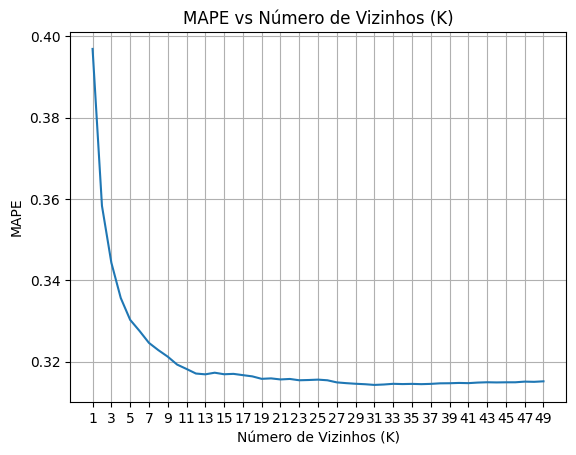

In [45]:
# Entendendo como a quantidade de vizinhos influencia na métrica MAPE
mape_values = []
for k in range(1, 50):
    model = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mape = mean_absolute_percentage_error(y_test,y_pred)
    mape_values.append(mape)

plt.plot(range(1, 50), mape_values)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('MAPE')
plt.title('MAPE vs Número de Vizinhos (K)')
plt.xticks(range(1, 50, 2))
plt.grid()
plt.show()

## Support Vector Machine (SVM) Regressor
O SVM Regressor é um algoritmo de aprendizado de máquina que busca encontrar uma função que se encaixe nos dados de treinamento, minimizando o erro e maximizando a margem de separação entre os dados. Ele é baseado no conceito de vetores de suporte, que são os pontos de dados mais próximos da função de regressão. O SVM Regressor é eficaz em casos de alta dimensionalidade e pode lidar com relações não lineares entre as variáveis.

In [32]:
from sklearn.svm import SVR

model = SVR()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mape = mean_absolute_percentage_error(y_test,y_pred)

print(f'MAPE: {mape}')

MAPE: 0.4214532788664194


In [33]:
from sklearn.svm import SVR

model = SVR(kernel='linear', C=100)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mape = mean_absolute_percentage_error(y_test,y_pred)

print(f'MAPE: {mape}')

MAPE: 0.3208912662881946


## Decision Tree Regressor
O Decision Tree Regressor é um algoritmo de aprendizado de máquina que utiliza uma estrutura de árvore para fazer previsões. Ele divide os dados em subconjuntos com base em características específicas, criando uma hierarquia de decisões. Cada nó da árvore representa uma decisão baseada em uma característica, e as folhas representam as previsões finais. O Decision Tree Regressor é fácil de interpretar e pode capturar relações complexas entre as variáveis.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mape = mean_absolute_percentage_error(y_test,y_pred)

print(f'MAPE: {mape}')

MAPE: 0.41053180747288676


## XGBoost Regressor
O XGBoost Regressor é um algoritmo de aprendizado de máquina baseado em árvores de decisão que utiliza o método de boosting para melhorar a precisão das previsões. Ele constrói uma série de árvores de decisão, onde cada árvore é treinada para corrigir os erros da árvore anterior. O XGBoost é conhecido por sua eficiência e desempenho em competições de aprendizado de máquina, e é amplamente utilizado para tarefas de regressão devido à sua capacidade de lidar com grandes conjuntos de dados e relações complexas entre as variáveis. Tem uma precisão muito boa e tem sido muito usado por profissionais de dados.

In [55]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mape = mean_absolute_percentage_error(y_test,y_pred)

print(f'MAPE: {mape}')

MAPE: 0.3115478188030054


In [57]:
# Ajustando os hiperparâmetros do XGBoost, esse são alguns dos exemplos de hiperparâmetros que podem ser ajustados.
params = {"n_estimators": 100,
           "max_depth": 6,
           "learning_rate": 0.1}

# Treinando o modelo
model = XGBRegressor(**params)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mape = mean_absolute_percentage_error(y_test,y_pred)

print(f'MAPE: {mape}')

MAPE: 0.30671574201583884
